# 👥 Analyse des performances des employés

## 🎯 Objectif
Analyser les performances et les heures travaillées afin d’identifier les écarts et les employés atypiques.

## 🧠 Problématique
Existe-t-il des différences significatives de performance entre les employés ? Peut-on détecter des outliers ?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("hr_dataset.csv")
df.head()

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,Michael Albert,22.0,LinkedIn,Exceeds,4.60,5,0,1/17/2019,0,1
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,...,Simon Roup,4.0,Indeed,Fully Meets,4.96,3,6,2/24/2016,0,17
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,3.02,3,0,5/15/2012,0,3
3,"Alagbe,Trina",10088,1,1,0,1,5,3,0,64991,...,Elijiah Gray,16.0,Indeed,Fully Meets,4.84,5,0,1/3/2019,0,15
4,"Anderson, Carol",10069,0,2,0,5,5,3,0,50825,...,Webster Butler,39.0,Google Search,Fully Meets,5.00,4,0,2/1/2016,0,2


In [4]:
df["EmpSatisfaction"].describe()

count    311.000000
mean       3.890675
std        0.909241
min        1.000000
25%        3.000000
50%        4.000000
75%        5.000000
max        5.000000
Name: EmpSatisfaction, dtype: float64

In [5]:
df["Salary"].describe()

count       311.000000
mean      69020.684887
std       25156.636930
min       45046.000000
25%       55501.500000
50%       62810.000000
75%       72036.000000
max      250000.000000
Name: Salary, dtype: float64

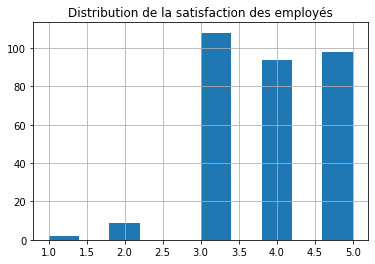

In [6]:
df["EmpSatisfaction"].hist()
plt.title("Distribution de la satisfaction des employés")
plt.show()

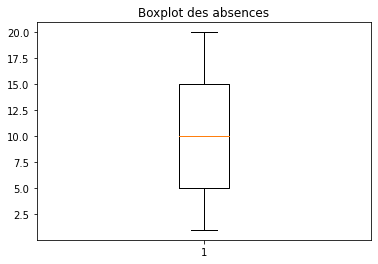

In [7]:
plt.boxplot(df["Absences"])
plt.title("Boxplot des absences")
plt.show()

In [11]:
Q1 = df["Absences"].quantile(0.25)
Q3 = df["Absences"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["Absences"] < lower) | (df["Absences"] > upper)]

outliers.head()

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences


In [12]:
Q1 = df["Absences"].quantile(0.25)
Q3 = df["Absences"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

Q1, Q3, lower, upper

(5.0, 15.0, -10.0, 30.0)

## Analyse des outliers (Absences)

Aucun outlier significatif n’a été détecté avec la méthode IQR sur la variable Absences.

Cela indique que les données sont relativement homogènes et qu’il n’existe pas de valeurs extrêmes marquées pour cet indicateur.

In [10]:
Q1 = df["Salary"].quantile(0.25)
Q3 = df["Salary"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["Absences"] < lower) | (df["Absences"] > upper)]

outliers.head()

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,Michael Albert,22.0,LinkedIn,Exceeds,4.60,5,0,1/17/2019,0,1
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,...,Simon Roup,4.0,Indeed,Fully Meets,4.96,3,6,2/24/2016,0,17
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,3.02,3,0,5/15/2012,0,3
3,"Alagbe,Trina",10088,1,1,0,1,5,3,0,64991,...,Elijiah Gray,16.0,Indeed,Fully Meets,4.84,5,0,1/3/2019,0,15
4,"Anderson, Carol",10069,0,2,0,5,5,3,0,50825,...,Webster Butler,39.0,Google Search,Fully Meets,5.00,4,0,2/1/2016,0,2


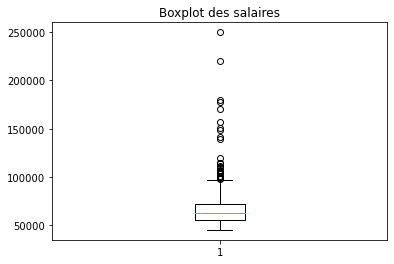

In [13]:
plt.boxplot(df["Salary"])
plt.title("Boxplot des salaires")
plt.show()

## 📊 Analyse des outliers (Salary)

Des outliers ont été détectés dans la variable Salary.

Cela indique que certains employés ont des salaires significativement plus élevés que la majorité.

Ces valeurs peuvent correspondre à des postes spécifiques (managers, experts) ou à des situations particulières dans l’entreprise.

In [14]:
df["EngagementSurvey"].describe()

count    311.000000
mean       4.110000
std        0.789938
min        1.120000
25%        3.690000
50%        4.280000
75%        4.700000
max        5.000000
Name: EngagementSurvey, dtype: float64

In [15]:
Q1 = df["EngagementSurvey"].quantile(0.25)
Q3 = df["EngagementSurvey"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

Q1, Q3, lower, upper

(3.69, 4.7, 2.175, 6.215000000000001)

In [16]:
outliers_engagement = df[
    (df["EngagementSurvey"] < lower) | 
    (df["EngagementSurvey"] > upper)
]

outliers_engagement

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
23,"Blount, Dianna",10294,0,0,0,1,5,2,0,66441,...,Michael Albert,22.0,CareerBuilder,Needs Improvement,2.00,3,0,2/27/2019,2,3
53,"Cole, Spencer",10292,0,0,1,4,5,2,0,59144,...,Kissy Sullivan,20.0,LinkedIn,Needs Improvement,2.00,3,0,5/1/2016,5,16
67,"Delarge, Alex",10306,0,0,1,1,6,1,0,61568,...,John Smith,17.0,Indeed,PIP,1.93,3,0,1/30/2019,6,5
69,"Desimone, Carl",10310,1,1,1,1,5,1,0,53189,...,Amy Dunn,11.0,Indeed,PIP,1.12,2,0,1/31/2019,4,9
86,"Exantus, Susan",10290,1,1,0,4,4,2,0,99280,...,Alex Sweetwater,10.0,Indeed,Needs Improvement,2.10,5,4,8/10/2012,4,19
90,"Fernandes, Nilson",10308,1,1,1,1,5,1,0,64057,...,Amy Dunn,11.0,Indeed,PIP,1.56,5,0,1/3/2019,6,15
91,"Fett, Boba",10309,0,0,1,1,3,1,0,53366,...,Peter Monroe,7.0,LinkedIn,PIP,1.20,3,6,2/4/2019,3,2
95,"Forrest, Alex",10305,1,1,1,1,6,3,0,70187,...,Lynn Daneault,21.0,Employee Referral,PIP,2.00,5,0,1/28/2019,4,7
267,"Stansfield, Norman",10307,1,1,1,1,6,1,0,58273,...,Lynn Daneault,21.0,Website,PIP,1.81,2,0,1/17/2019,3,5


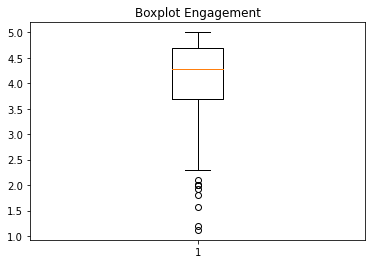

In [17]:
plt.boxplot(df["EngagementSurvey"])
plt.title("Boxplot Engagement")
plt.show()

## 📊 Analyse des outliers (Engagement)

Le boxplot de l’engagement montre que la majorité des employés présentent un niveau d’engagement relativement élevé, avec une médiane située autour de 4.

Cependant, plusieurs valeurs atypiques (outliers) apparaissent en dessous de la distribution principale, indiquant l’existence d’employés ayant un niveau d’engagement significativement plus faible.

Ces cas peuvent refléter des situations spécifiques telles que :
- un manque de motivation
- une surcharge ou insatisfaction au travail
- des conditions de travail défavorables

L’identification de ces outliers est importante car elle permet de cibler les employés à risque et d’envisager des actions d’amélioration au sein de l’entreprise.

In [18]:
outliers_engagement[["Salary", "EngagementSurvey"]]

,Salary,EngagementSurvey
23,66441,2.00
53,59144,2.00
67,61568,1.93
69,53189,1.12
86,99280,2.10
90,64057,1.56
91,53366,1.20
95,70187,2.00
267,58273,1.81


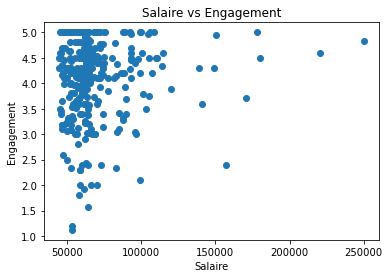

In [19]:
plt.scatter(df["Salary"], df["EngagementSurvey"])
plt.xlabel("Salaire")
plt.ylabel("Engagement")
plt.title("Salaire vs Engagement")
plt.show()

In [21]:
df["PerformanceScore"].value_counts()

Fully Meets          243
Exceeds               37
Needs Improvement     18
PIP                   13
Name: PerformanceScore, dtype: int64

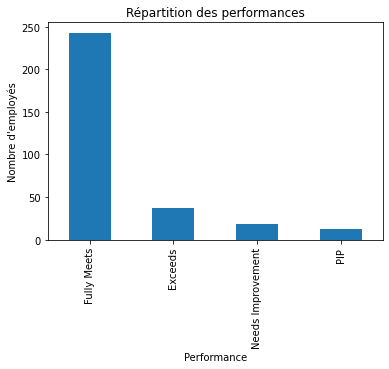

In [22]:
df["PerformanceScore"].value_counts().plot(kind="bar")
plt.title("Répartition des performances")
plt.xlabel("Performance")
plt.ylabel("Nombre d'employés")
plt.show()

## 📊 Analyse de la performance

La majorité des employés atteignent les objectifs ("Fully Meets"), ce qui indique un niveau global de performance satisfaisant.

Une proportion plus faible d’employés dépasse les attentes ("Exceeds"), représentant les profils les plus performants.

Enfin, un nombre limité d’employés présente des performances en dessous des attentes, ce qui peut nécessiter des actions d’accompagnement ou de formation.

In [23]:
pd.crosstab(df["PerformanceScore"], df["EmpSatisfaction"])

EmpSatisfaction,1,2,3,4,5
PerformanceScore,,,,,
Exceeds,0,0,11,11,15
Fully Meets,0,1,87,78,77
Needs Improvement,0,2,7,5,4
PIP,2,6,3,0,2


In [24]:
df.groupby("PerformanceScore")["EmpSatisfaction"].mean()

PerformanceScore
Exceeds              4.108108
Fully Meets          3.950617
Needs Improvement    3.611111
PIP                  2.538462
Name: EmpSatisfaction, dtype: float64

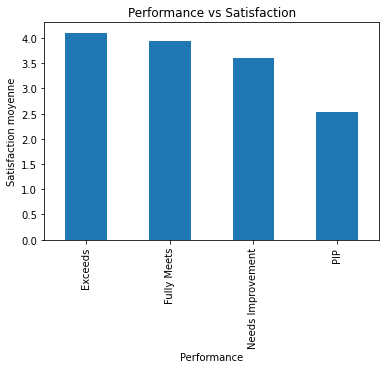

In [26]:
df.groupby("PerformanceScore")["EmpSatisfaction"].mean().plot(kind="bar")

plt.title("Performance vs Satisfaction")
plt.xlabel("Performance")
plt.ylabel("Satisfaction moyenne")
plt.show()

## 📊 Analyse croisée performance / satisfaction

L’analyse montre que les employés ayant les meilleures performances présentent également un niveau de satisfaction plus élevé.

À l’inverse, les employés ayant des performances plus faibles affichent un niveau de satisfaction plus bas.

Cela suggère une relation positive entre la satisfaction au travail et la performance des employés.

Améliorer la satisfaction des employés pourrait donc contribuer à améliorer leurs performances.

In [28]:
pd.crosstab(df["PerformanceScore"], df["EngagementSurvey"])

EngagementSurvey,1.12,1.20,1.56,1.81,1.93,2.00,2.10,2.30,2.33,2.34,...,4.78,4.80,4.81,4.83,4.84,4.88,4.90,4.94,4.96,5.00
PerformanceScore,,,,,,,,,,,,,,,,,,,,,
Exceeds,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,8
Fully Meets,0,0,0,0,0,0,0,0,0,0,...,1,3,1,2,1,1,1,1,2,47
Needs Improvement,0,0,0,0,0,2,1,1,0,1,...,0,0,0,0,0,0,0,0,0,1
PIP,1,1,1,1,1,1,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0


In [29]:
df.groupby("PerformanceScore")["EngagementSurvey"].mean()

PerformanceScore
Exceeds              4.478649
Fully Meets          4.237901
Needs Improvement    2.991111
PIP                  2.219231
Name: EngagementSurvey, dtype: float64

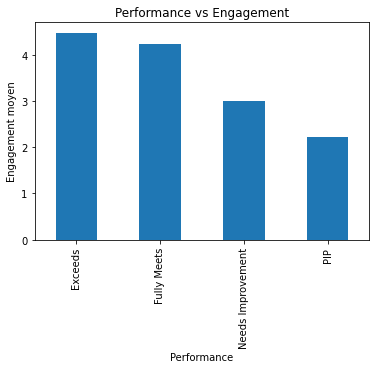

In [30]:
df.groupby("PerformanceScore")["EngagementSurvey"].mean().plot(kind="bar")

plt.title("Performance vs Engagement")
plt.xlabel("Performance")
plt.ylabel("Engagement moyen")
plt.show()

## 📊 Analyse performance / engagement

Les employés ayant les meilleures performances présentent un niveau d’engagement plus élevé.

À l’inverse, les employés moins performants affichent un engagement plus faible.

Cela suggère que l’implication des employés joue un rôle important dans leur performance.

In [31]:
pd.crosstab(df["PerformanceScore"], df["EngagementSurvey"])

EngagementSurvey,1.12,1.20,1.56,1.81,1.93,2.00,2.10,2.30,2.33,2.34,...,4.78,4.80,4.81,4.83,4.84,4.88,4.90,4.94,4.96,5.00
PerformanceScore,,,,,,,,,,,,,,,,,,,,,
Exceeds,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,8
Fully Meets,0,0,0,0,0,0,0,0,0,0,...,1,3,1,2,1,1,1,1,2,47
Needs Improvement,0,0,0,0,0,2,1,1,0,1,...,0,0,0,0,0,0,0,0,0,1
PIP,1,1,1,1,1,1,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0


In [32]:
df.groupby("PerformanceScore")["Salary"].mean()

PerformanceScore
Exceeds              77144.864865
Fully Meets          68366.720165
Needs Improvement    68407.555556
PIP                  58971.076923
Name: Salary, dtype: float64

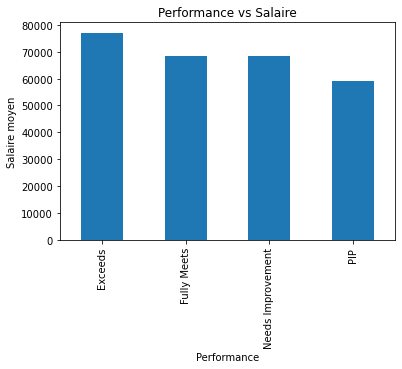

In [33]:
df.groupby("PerformanceScore")["Salary"].mean().plot(kind="bar")

plt.title("Performance vs Salaire")
plt.xlabel("Performance")
plt.ylabel("Salaire moyen")
plt.show()

## 📊 Analyse performance / salaire

Les employés les plus performants tendent à avoir un salaire moyen plus élevé.

Cela peut s’expliquer par des politiques de rémunération basées sur la performance.

Cependant, l’écart de salaire entre les catégories de performance peut varier selon les postes et les responsabilités.

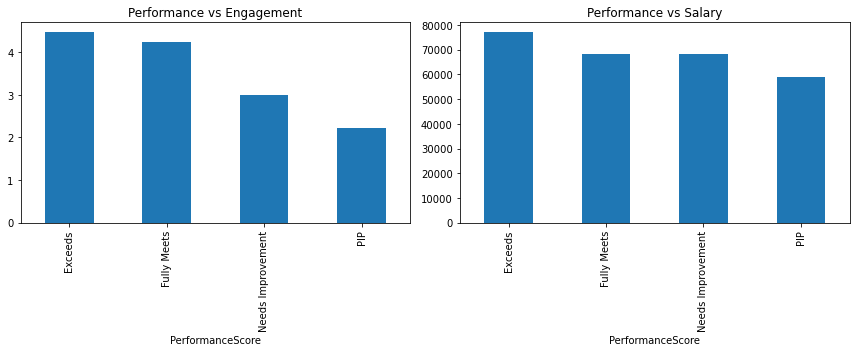

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

df.groupby("PerformanceScore")["EngagementSurvey"].mean().plot(kind="bar", ax=axes[0])
axes[0].set_title("Performance vs Engagement")

df.groupby("PerformanceScore")["Salary"].mean().plot(kind="bar", ax=axes[1])
axes[1].set_title("Performance vs Salary")

plt.tight_layout()
plt.show()

## 📊 Insights clés

### 1. Distribution globale des performances
La majorité des employés atteignent les objectifs fixés ("Fully Meets"), ce qui indique un niveau de performance globalement satisfaisant au sein de l’entreprise.

### 2. Engagement des employés
L’analyse de l’engagement montre que la plupart des employés présentent un niveau élevé d’implication. Cependant, quelques outliers avec un engagement faible ont été identifiés, ce qui peut signaler des risques de désengagement ou de démotivation.

### 3. Analyse des salaires
La distribution des salaires révèle des écarts importants entre les employés. La présence d’outliers indique que certains salariés perçoivent des rémunérations significativement plus élevées, probablement en raison de postes à responsabilité ou de compétences spécifiques.

### 4. Relation entre performance et engagement
Les employés les plus performants affichent en moyenne un niveau d’engagement plus élevé. Cela suggère une relation positive entre implication au travail et performance.

### 5. Relation entre performance et salaire
Les employés ayant les meilleures performances tendent à bénéficier de salaires plus élevés. Cela reflète probablement une politique de rémunération basée sur la performance, bien que des variations puissent exister selon les fonctions.

### 6. Identification des profils à risque
Les employés présentant un faible engagement et/ou une performance inférieure constituent des profils à surveiller. Ces cas peuvent nécessiter des actions ciblées telles que des formations, un accompagnement managérial ou une réorganisation du travail.

## ✅ Conclusion

Cette analyse des données RH a permis de mieux comprendre les dynamiques de performance, d’engagement et de rémunération au sein de l’entreprise.

Les résultats montrent que la majorité des employés atteignent les objectifs fixés et présentent un niveau d’engagement élevé. Toutefois, des écarts significatifs ont été identifiés, notamment en termes de salaires et d’implication.

L’analyse croisée met en évidence une relation entre la performance, l’engagement et la rémunération, suggérant que ces facteurs sont interdépendants.

Enfin, la détection des outliers permet d’identifier des situations atypiques, qu’il s’agisse de salariés très performants ou, au contraire, de profils à risque nécessitant une attention particulière.

Ce type d’analyse constitue un outil précieux pour les ressources humaines afin d’améliorer la gestion des talents, optimiser la performance globale et renforcer l’engagement des employés.